# BloomBench — global coverage map

Visualize where every observation in [BloomBench](../src/pysephone/benchmarks/bloombench/) lives on the globe. The benchmark spans three families — PEP725 (Europe), GMU Cherry (Japan / Switzerland / South Korea), USA-NPN (North America) — covering 18 (dataset, target) pairs.

Flow:

1. **Load** every dataset from [`bloombench.config.DATASETS_REQUESTED`](../src/pysephone/benchmarks/bloombench/config.py) at observation level only — no climate features, so this is fast and runs offline once the registries are warmed.
2. **Aggregate** to a per-(dataset, location) table with sample counts and year ranges.
3. **Plot** a global overview, regional zooms, and a per-dataset summary.

The basemap is fetched once from the Natural Earth GitHub mirror (~230 KB) and cached under `<data_root>/data/products/natural_earth/`. No CDS / Copernicus credentials needed.

## 1. Setup

In [1]:
from __future__ import annotations

from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from pysephone.benchmarks.bloombench import config as bb_config
from pysephone.constants import KEY_LAT, KEY_LON
from pysephone.dataset.dataset import Dataset
from pysephone.paths import get_data_root, get_products_data_dir

print(f'Datasets requested: {len(bb_config.DATASETS_REQUESTED)}')
print(f'Data root:          {get_data_root()}')

Datasets requested: 18
Data root:          C:\Users\bree026\Repositories\pysephone


## 2. Load every dataset (observations only)

`Dataset.load(name)` with no feature provider just runs the dataset builder, which loads / parses the local source files for PEP725, GMU Cherry, and USA-NPN. No climate downloads happen here.

In [2]:
loaded: dict[str, Dataset] = {}
load_rows: list[dict] = []

for ds_name, target_key in bb_config.DATASETS_REQUESTED:
    try:
        ds = Dataset.load(ds_name)
    except Exception as exc:  # noqa: BLE001 — surface per-row
        load_rows.append(dict(dataset=ds_name, status=f'LOAD FAIL: {type(exc).__name__}: {exc}'))
        print(f'  [{ds_name:28s}] LOAD FAILED: {type(exc).__name__}: {exc}')
        continue
    n = len(ds)
    n_loc = len(set(ds.observations.locations))
    years = ds.observations.years
    load_rows.append(dict(
        dataset=ds_name, target=target_key,
        n_samples=n, n_locations=n_loc,
        year_min=min(years) if years else None,
        year_max=max(years) if years else None,
        status='ok',
    ))
    loaded[ds_name] = ds
    print(f'  [{ds_name:28s}] n={n:5d}  locations={n_loc:5d}  years={min(years)}-{max(years)}')

print(f'\nLoaded {len(loaded)} / {len(bb_config.DATASETS_REQUESTED)} datasets.')
pd.DataFrame(load_rows)

Checking for missing PEP725 data:   0%|          | 0/174 [00:00<?, ?it/s]

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 17404.17it/s]

  [PEP725_Apple                ] n= 6761  locations=  836  years=1986-2015


Checking for missing PEP725 data:   0%|          | 0/174 [00:00<?, ?it/s]

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 16926.24it/s]

...

  [USA_NPN_Apple               ] n=  205  locations=  107  years=2009-2024
  [USA_NPN_Pear                ] n=  106  locations=   66  years=2014-2024


  [USA_NPN_Peach               ] n=   84  locations=   41  years=2009-2024
  [USA_NPN_Almond              ] n=    2  locations=    2  years=2013-2023


  [USA_NPN_Apricot             ] n=   23  locations=    8  years=2015-2024
  [USA_NPN_Plum                ] n=   95  locations=   47  years=2009-2024


  [USA_NPN_Cherry              ] n=  470  locations=  208  years=2009-2024

Loaded 18 / 18 datasets.


,dataset,target,n_samples,n_locations,year_min,year_max,status
0,PEP725_Apple,BBCH_60,6761,836,1986,2015,ok
1,PEP725_Pear,BBCH_60,3284,590,1986,2015,ok
2,PEP725_Peach,BBCH_60,993,391,1986,2015,ok
3,PEP725_Almond,BBCH_60,153,20,1986,2015,ok
4,PEP725_Apricot,BBCH_60,190,70,1986,2016,ok
5,PEP725_Plum,BBCH_60,3104,622,1986,2016,ok
6,PEP725_Cherry_NoGMU,BBCH_60,7472,1062,1986,2016,ok
7,GMU_Cherry_Japan_Y,gmu_0,1997,67,1986,2021,ok
8,GMU_Cherry_Japan_S,gmu_0,225,8,1986,2021,ok
9,GMU_Cherry_Switzerland,gmu_1,1080,67,1986,2021,ok


## 3. Per-(dataset, location) table

Aggregate to one row per (dataset × location) with sample count, year range, and lat / lon. This is what every plot below renders.

In [3]:
FAMILY_OF = lambda name: (
    'PEP725'   if name.startswith('PEP725_')   else
    'GMU'      if name.startswith('GMU_')      else
    'USA-NPN'  if name.startswith('USA_NPN_')  else
    'Other'
)

def species_label(ds_name: str) -> str:
    # Strip family prefix and pretty-print the rest.
    for pfx in ('PEP725_', 'GMU_Cherry_', 'USA_NPN_'):
        if ds_name.startswith(pfx):
            tail = ds_name[len(pfx):]
            # GMU_Cherry_Japan_Y / _S — yedoensis / sargentii
            if tail == 'Japan_Y': return 'Cherry (Japan, yedoensis)'
            if tail == 'Japan_S': return 'Cherry (Japan, sargentii)'
            if pfx == 'GMU_Cherry_': return f'Cherry ({tail.replace("_", " ")})'
            return tail.replace('_', ' ')
    return ds_name

rows: list[dict] = []
for ds_name, ds in loaded.items():
    obs = ds.observations
    df_y = obs.df_y
    # Per-location sample count = number of distinct (year, species, subgroup, obs_type) tuples
    counts = df_y.groupby(level=['src', 'loc_id']).size().rename('n_samples')
    years_per_loc = (df_y.reset_index().groupby(['src', 'loc_id'])['year']
                          .agg(['min', 'max']).rename(columns={'min': 'y0', 'max': 'y1'}))
    for (src, loc_id), n in counts.items():
        coords = obs.get_location_coordinates((src, loc_id))
        rows.append(dict(
            dataset=ds_name,
            family=FAMILY_OF(ds_name),
            species=species_label(ds_name),
            src=src, loc_id=loc_id,
            lat=coords[KEY_LAT], lon=coords[KEY_LON],
            n_samples=int(n),
            year_min=int(years_per_loc.loc[(src, loc_id), 'y0']),
            year_max=int(years_per_loc.loc[(src, loc_id), 'y1']),
        ))

loc_df = pd.DataFrame(rows)
print(f'Total (dataset × location) rows: {len(loc_df):,}')
print(f'Unique locations (lat, lon):     {loc_df[["lat", "lon"]].drop_duplicates().shape[0]:,}')
print(f'Total observations:              {loc_df["n_samples"].sum():,}')
loc_df.head()

Total (dataset × location) rows: 4,264
Unique locations (lat, lon):     2,251
Total observations:              26,749


,dataset,family,species,src,loc_id,lat,lon,n_samples,year_min,year_max
0,PEP725_Apple,PEP725,Apple,pep725,1,54.7667,9.43333,8,1991,1999
1,PEP725_Apple,PEP725,Apple,pep725,3,54.3333,10.15000,12,1993,2005
2,PEP725_Apple,PEP725,Apple,pep725,4,54.3167,10.05000,8,2007,2015
3,PEP725_Apple,PEP725,Apple,pep725,5,53.8833,10.68330,1,1993,1993
4,PEP725_Apple,PEP725,Apple,pep725,13,54.6167,9.98333,1,1991,1991


## 4. Basemap

Natural Earth 110 m countries, fetched once and cached locally. No cartopy / geodatasets dependency — just `requests` + `geopandas`.

In [4]:
WORLD_URL = (
    'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/'
    'master/geojson/ne_110m_admin_0_countries.geojson'
)

def get_world_geojson() -> gpd.GeoDataFrame:
    cache = get_products_data_dir(get_data_root()) / 'natural_earth' / 'ne_110m_admin_0_countries.geojson'
    if not cache.exists():
        cache.parent.mkdir(parents=True, exist_ok=True)
        print(f'Downloading Natural Earth basemap → {cache}')
        resp = requests.get(WORLD_URL, timeout=60)
        resp.raise_for_status()
        cache.write_bytes(resp.content)
    return gpd.read_file(cache)

world = get_world_geojson()
print(f'Basemap: {len(world)} country polygons')

Basemap: 177 country polygons


## 5. Colour palette

One hue per family on the global map; a distinct colour per species inside the regional zooms.

In [5]:
FAMILY_COLORS = {
    'PEP725':  '#1f77b4',  # blue
    'GMU':     '#d62728',  # red
    'USA-NPN': '#2ca02c',  # green
}

SPECIES_ORDER = sorted(loc_df['species'].unique())
cmap_species = plt.get_cmap('tab20', len(SPECIES_ORDER))
SPECIES_COLORS = {sp: cmap_species(i) for i, sp in enumerate(SPECIES_ORDER)}

def marker_size(n: np.ndarray, *, lo: float = 8.0, hi: float = 220.0) -> np.ndarray:
    # Log-scaled marker area so a station with 1000 samples isn't 1000× larger.
    x = np.log10(np.asarray(n, dtype=float) + 1)
    if x.max() == x.min():
        return np.full_like(x, (lo + hi) / 2)
    return lo + (hi - lo) * (x - x.min()) / (x.max() - x.min())

print(f'Species in palette: {len(SPECIES_ORDER)}')

Species in palette: 12


## 6. Global overview

All locations on a single world map, coloured by family and sized by sample count (log-scaled). Datasets within the same family share a hue so the geographic split is obvious at a glance.

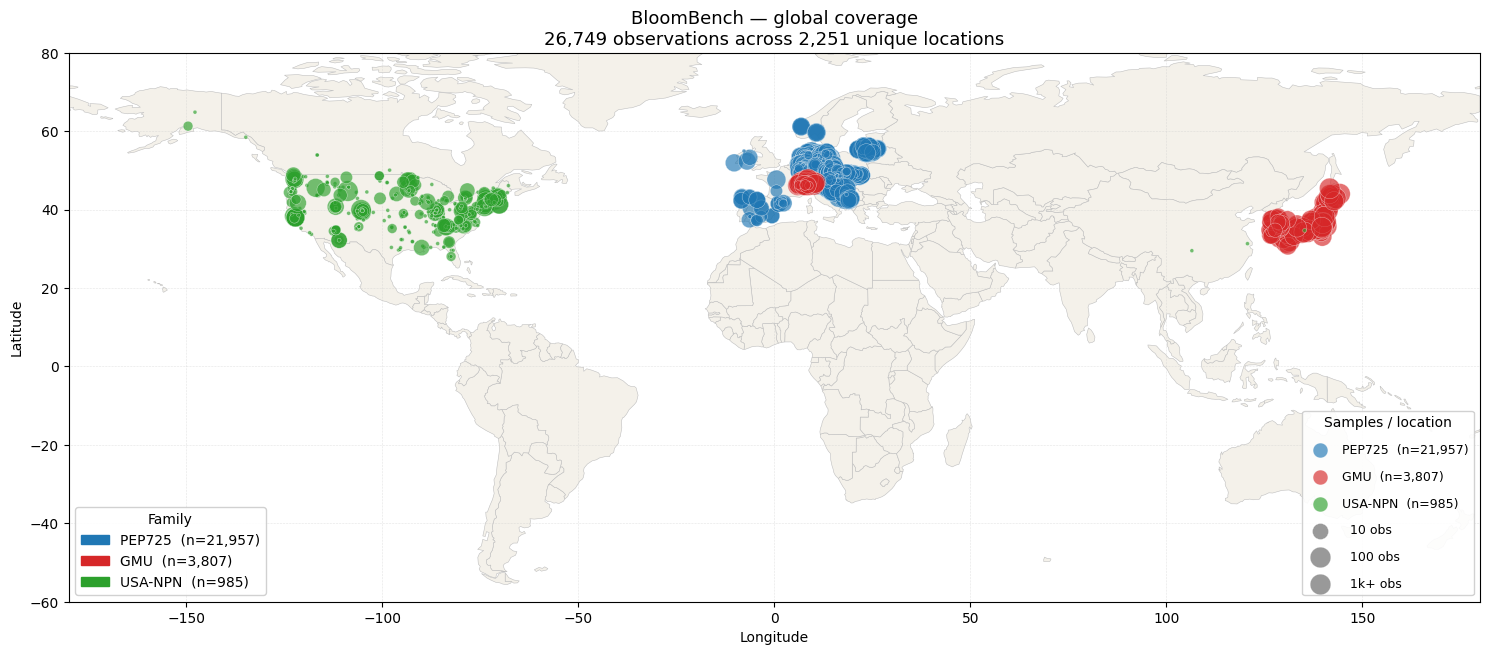

In [6]:
fig, ax = plt.subplots(figsize=(15, 7.5))
world.plot(ax=ax, color='#f4f1ea', edgecolor='#bfbfbf', linewidth=0.4)

# Family-level totals (for legend labels)
family_totals = loc_df.groupby('family')['n_samples'].sum()

sizes_all = marker_size(loc_df['n_samples'].values)
for fam, color in FAMILY_COLORS.items():
    sub = loc_df[loc_df['family'] == fam]
    if sub.empty:
        continue
    sub_sizes = marker_size(sub['n_samples'].values, lo=8.0, hi=220.0)
    ax.scatter(sub['lon'], sub['lat'], s=sub_sizes, c=color, alpha=0.65,
               edgecolor='white', linewidth=0.3, zorder=3,
               label=f'{fam}  (n={int(family_totals.get(fam, 0)):,})')

ax.set_xlim(-180, 180); ax.set_ylim(-60, 80)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('BloomBench — global coverage\n'
             f'{loc_df["n_samples"].sum():,} observations across '
             f'{loc_df[["lat", "lon"]].drop_duplicates().shape[0]:,} unique locations',
             fontsize=13)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', linewidth=0.4, color='#cccccc')
ax.legend(loc='lower left', frameon=True, framealpha=0.9, fontsize=10, title='Family')

# Sample-count legend (3 fixed sizes)
for n_ref, label in [(10, '10'), (100, '100'), (1000, '1k+')]:
    s_ref = marker_size(np.array([n_ref, 1, loc_df['n_samples'].max()]))[0]
    ax.scatter([], [], s=s_ref, c='#555', alpha=0.6, edgecolor='white', linewidth=0.3,
               label=f'  {label} obs')
leg2 = ax.legend(loc='lower right', frameon=True, framealpha=0.9, fontsize=9,
                 title='Samples / location', labelspacing=1.1)
ax.add_artist(leg2)
# Re-add the family legend on top
handles_fam = [mpatches.Patch(color=c, label=f'{fam}  (n={int(family_totals.get(fam, 0)):,})')
               for fam, c in FAMILY_COLORS.items() if fam in family_totals.index]
ax.legend(handles=handles_fam, loc='lower left', frameon=True, framealpha=0.9,
          fontsize=10, title='Family')

plt.tight_layout()
plt.show()

## 7. Regional zooms

Three panels at matching scale — one per family — coloured by species so the within-region composition is visible.

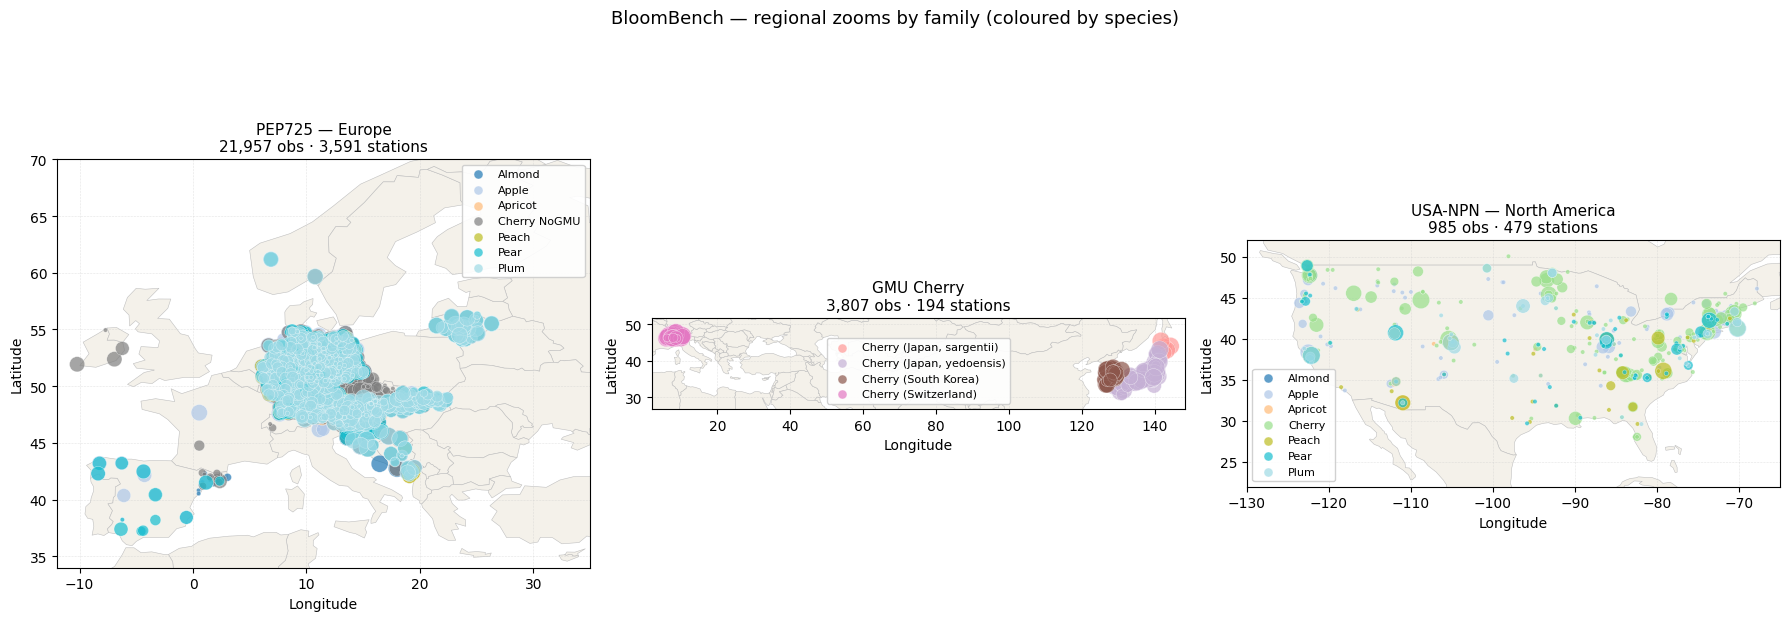

In [7]:
REGIONS = [
    ('PEP725 — Europe',         'PEP725',  (-12.0,  35.0, 34.0, 70.0)),
    ('GMU Cherry',              'GMU',     None),  # auto-extent from data
    ('USA-NPN — North America', 'USA-NPN', (-130.0, -65.0, 22.0, 52.0)),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
for ax, (title, fam, extent) in zip(axes, REGIONS):
    sub = loc_df[loc_df['family'] == fam]
    if extent is None and not sub.empty:
        pad = 4.0
        extent = (sub['lon'].min() - pad, sub['lon'].max() + pad,
                  sub['lat'].min() - pad, sub['lat'].max() + pad)
    world.plot(ax=ax, color='#f4f1ea', edgecolor='#bfbfbf', linewidth=0.4)

    for sp in sorted(sub['species'].unique()):
        sp_sub = sub[sub['species'] == sp]
        sizes = marker_size(sp_sub['n_samples'].values, lo=10, hi=160)
        ax.scatter(sp_sub['lon'], sp_sub['lat'], s=sizes,
                   c=[SPECIES_COLORS[sp]], alpha=0.7,
                   edgecolor='white', linewidth=0.3, zorder=3, label=sp)

    x0, x1, y0, y1 = extent
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\n{sub["n_samples"].sum():,} obs · {len(sub):,} stations', fontsize=11)
    ax.grid(True, linestyle=':', linewidth=0.4, color='#cccccc')
    ax.legend(loc='best', fontsize=8, frameon=True, framealpha=0.9, markerscale=0.7)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

fig.suptitle('BloomBench — regional zooms by family (coloured by species)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Per-dataset summary

Side-by-side: sample count per dataset (left) and temporal coverage (right). Bars are coloured by family to tie the plots back to the maps above.

C:\Users\bree026\AppData\Local\Temp\ipykernel_36084\493040820.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


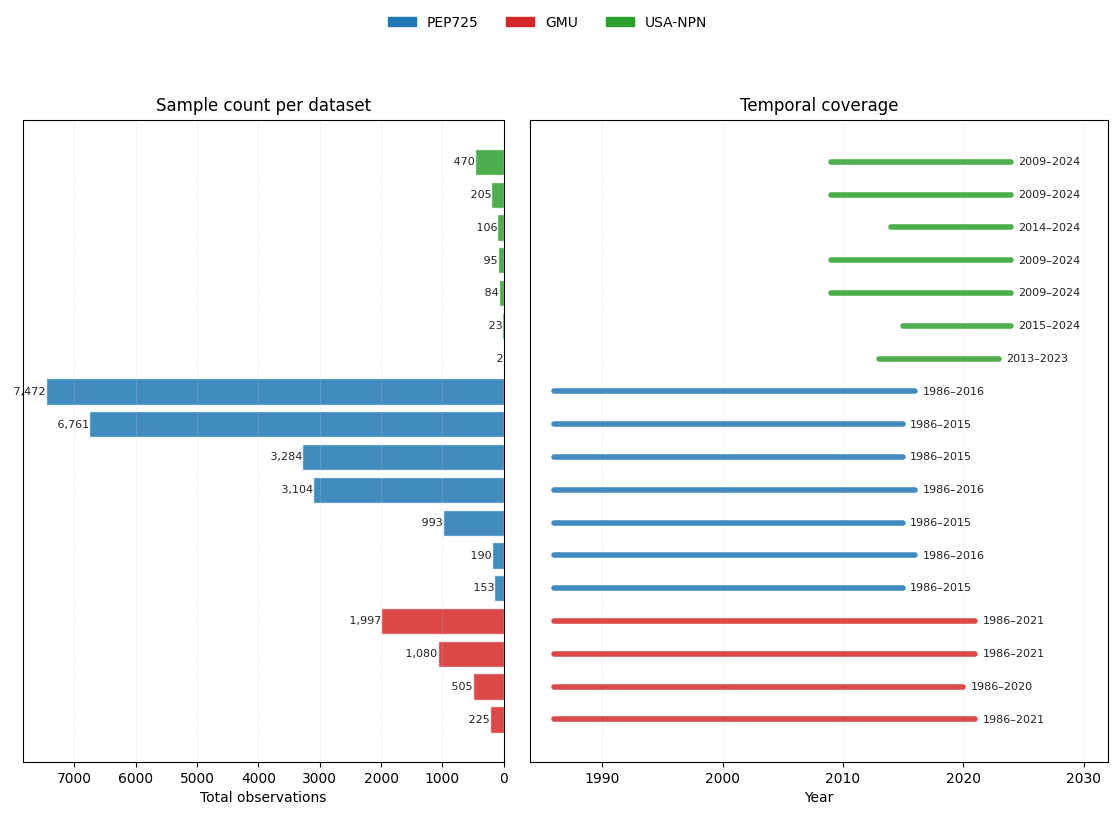

,dataset,family,n_samples,n_locations,year_min,year_max
0,GMU_Cherry_Japan_S,GMU,225,8,1986,2021
1,GMU_Cherry_South_Korea,GMU,505,52,1986,2020
2,GMU_Cherry_Switzerland,GMU,1080,67,1986,2021
3,GMU_Cherry_Japan_Y,GMU,1997,67,1986,2021
4,PEP725_Almond,PEP725,153,20,1986,2015
5,PEP725_Apricot,PEP725,190,70,1986,2016
6,PEP725_Peach,PEP725,993,391,1986,2015
7,PEP725_Plum,PEP725,3104,622,1986,2016
8,PEP725_Pear,PEP725,3284,590,1986,2015
9,PEP725_Apple,PEP725,6761,836,1986,2015


In [8]:
per_ds = (loc_df.groupby(['dataset', 'family'], as_index=False)
                .agg(n_samples=('n_samples', 'sum'),
                     n_locations=('loc_id', 'size'),
                     year_min=('year_min', 'min'),
                     year_max=('year_max', 'max')))
per_ds = per_ds.sort_values(['family', 'n_samples'], ascending=[True, True])

fig, (ax_bar, ax_yrs) = plt.subplots(
    1, 2, figsize=(14, 0.38 * len(per_ds) + 1.5),
    gridspec_kw={'width_ratios': [1.0, 1.2], 'wspace': 0.05},
    sharey=True,
)

y = np.arange(len(per_ds))
colors = [FAMILY_COLORS[f] for f in per_ds['family']]
ax_bar.barh(y, per_ds['n_samples'], color=colors, alpha=0.85, edgecolor='white')
ax_bar.set_yticks(y); ax_bar.set_yticklabels(per_ds['dataset'])
ax_bar.invert_xaxis()
ax_bar.yaxis.tick_right()
ax_bar.set_xlabel('Total observations')
ax_bar.set_title('Sample count per dataset')
ax_bar.grid(True, axis='x', linestyle=':', linewidth=0.4, color='#cccccc')
for yi, n in zip(y, per_ds['n_samples']):
    ax_bar.text(n, yi, f' {int(n):,}', va='center', ha='right', fontsize=8, color='#222')

# Year spans
for yi, (_, row) in zip(y, per_ds.iterrows()):
    ax_yrs.plot([row['year_min'], row['year_max']], [yi, yi],
                color=FAMILY_COLORS[row['family']], linewidth=4, alpha=0.85,
                solid_capstyle='round')
    ax_yrs.text(row['year_max'] + 0.6, yi, f'{int(row["year_min"])}–{int(row["year_max"])}',
                va='center', fontsize=8, color='#222')
ax_yrs.set_xlabel('Year')
ax_yrs.set_title('Temporal coverage')
ax_yrs.grid(True, axis='x', linestyle=':', linewidth=0.4, color='#cccccc')
ax_yrs.set_xlim(per_ds['year_min'].min() - 2, per_ds['year_max'].max() + 8)
ax_yrs.set_yticks([])

# Shared legend
handles = [mpatches.Patch(color=c, label=fam) for fam, c in FAMILY_COLORS.items()]
fig.legend(handles=handles, loc='upper center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.02), fontsize=10)

plt.tight_layout()
plt.show()

per_ds.reset_index(drop=True)

## 9. Headline totals

One-line counters useful for figure captions / paper text.

In [9]:
n_obs       = int(loc_df['n_samples'].sum())
n_locs      = loc_df[['lat', 'lon']].drop_duplicates().shape[0]
n_stations  = loc_df[['src', 'loc_id']].drop_duplicates().shape[0]
n_datasets  = loc_df['dataset'].nunique()
n_species   = loc_df['species'].nunique()
year_min    = int(loc_df['year_min'].min())
year_max    = int(loc_df['year_max'].max())

print(f'BloomBench — {n_datasets} datasets · {n_species} species · '
      f'{n_stations:,} stations ({n_locs:,} unique lat/lon)')
print(f'  Observations:   {n_obs:,}')
print(f'  Temporal span:  {year_min} – {year_max}  ({year_max - year_min + 1} years)')
print(f'  By family:')
for fam, n in loc_df.groupby('family')['n_samples'].sum().sort_values(ascending=False).items():
    print(f'    {fam:8s}  {int(n):>8,}  observations')

BloomBench — 18 datasets · 12 species · 2,265 stations (2,251 unique lat/lon)
  Observations:   26,749
  Temporal span:  1986 – 2024  (39 years)
  By family:
    PEP725      21,957  observations
    GMU          3,807  observations
    USA-NPN        985  observations
